## PART I                                                                                                                                                                          __*Using the “statsmodels” package with focus on interpretation and explanation*__

/Users/karimsouidi/opt/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:2580: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)
/Users/karimsouidi/opt/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:2580: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)



Original Model Results:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     819.1
Date:                Thu, 09 Jan 2025   Prob (F-statistic):          2.63e-268
Time:                        19:50:59   Log-Likelihood:                -12311.
No. Observations:                1000   AIC:                         2.463e+04
Df Residuals:                     996   BIC:                         2.465e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1.9

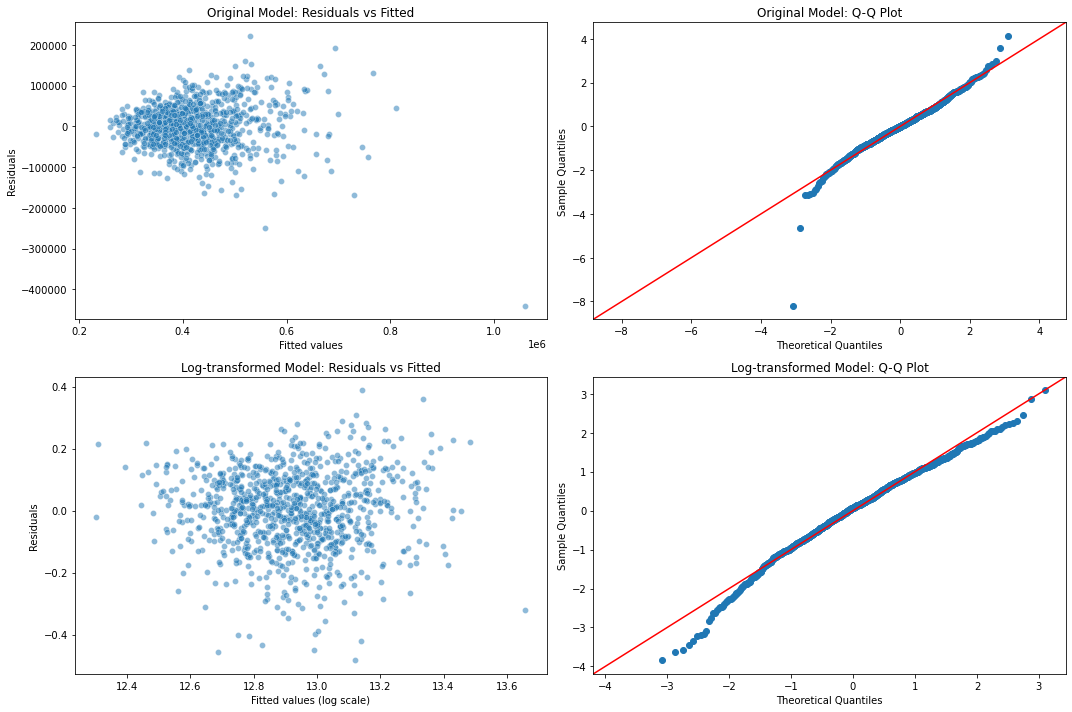


VIF for Original Model:
         Variable        VIF
0           const  14.506181
1  square_footage   1.000278
2             age   1.003549
3        bedrooms   1.003271

VIF for Log-transformed Model:
         Variable         VIF
0           const  375.076563
1  square_footage    1.000576
2             age    1.003846
3        bedrooms    1.003279

Breusch-Pagan test for Original Model:
LM stat       1.854479e+02
LM p-value    5.873136e-40
F stat        7.558597e+01
F p-value     4.731483e-44
dtype: float64

Breusch-Pagan test for Log-transformed Model:
LM stat       5.886255e+01
LM p-value    1.028533e-12
F stat        2.076463e+01
F p-value     4.702575e-13
dtype: float64


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)
n_samples = 1000

# Generate predictor variables
square_footage = np.random.lognormal(mean=7.5, sigma=0.4, size=n_samples)
age = np.random.uniform(0, 50, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)

# Generate house prices with non-linear relationships and heteroscedasticity
base_price = 200000 + (square_footage * 100) + \
            (50000 * np.log(bedrooms)) - \
            (1000 * age) + \
            (np.random.normal(0, 50000 * (square_footage/np.mean(square_footage)), n_samples))

# Create DataFrame
df = pd.DataFrame({
    'price': base_price,
    'square_footage': square_footage,
    'age': age,
    'bedrooms': bedrooms
})

# Original Model
X = df[['square_footage', 'age', 'bedrooms']]
y = df['price']
X = sm.add_constant(X)  # Add constant term

# Fit the model
model1 = sm.OLS(y, X).fit()
print("\nOriginal Model Results:")
print(model1.summary())

# Log-transformed Model
X_log = df[['square_footage', 'age', 'bedrooms']].copy()
X_log['square_footage'] = np.log(X_log['square_footage'])
y_log = np.log(df['price'])
X_log = sm.add_constant(X_log)

model2 = sm.OLS(y_log, X_log).fit()
print("\nLog-transformed Model Results:")
print(model2.summary())

# Create diagnostic plots for both models
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original Model Residual Plot
residuals1 = model1.resid
fitted1 = model1.fittedvalues
sns.scatterplot(x=fitted1, y=residuals1, alpha=0.5, ax=axes[0,0])
axes[0,0].set_xlabel('Fitted values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Original Model: Residuals vs Fitted')

# Original Model QQ Plot
sm.graphics.qqplot(residuals1, line='45', fit=True, ax=axes[0,1])
axes[0,1].set_title('Original Model: Q-Q Plot')

# Log-transformed Model Residual Plot
residuals2 = model2.resid
fitted2 = model2.fittedvalues
sns.scatterplot(x=fitted2, y=residuals2, alpha=0.5, ax=axes[1,0])
axes[1,0].set_xlabel('Fitted values (log scale)')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Log-transformed Model: Residuals vs Fitted')

# Log-transformed Model QQ Plot
sm.graphics.qqplot(residuals2, line='45', fit=True, ax=axes[1,1])
axes[1,1].set_title('Log-transformed Model: Q-Q Plot')

plt.tight_layout()
plt.show()

# Calculate VIF for both models
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data


print("\nVIF for Original Model:")
print(calculate_vif(X))
print("\nVIF for Log-transformed Model:")
print(calculate_vif(X_log))

# Perform Breusch-Pagan test for heteroscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan

def perform_heteroscedasticity_test(model):
    bp_test = het_breuschpagan(model.resid, model.model.exog)
    return pd.Series({
        'LM stat': bp_test[0],
        'LM p-value': bp_test[1],
        'F stat': bp_test[2],
        'F p-value': bp_test[3]
    })

print("\nBreusch-Pagan test for Original Model:")
print(perform_heteroscedasticity_test(model1))
print("\nBreusch-Pagan test for Log-transformed Model:")
print(perform_heteroscedasticity_test(model2))

## Model II __*Using the “sklearn.model_selection” package with focus on prediction*__


Model Performance Comparison:
             Model  R-squared          RMSE
0         Original   0.629619  60598.041947
1  Log-transformed   0.689352      0.128276
2      Square root   0.686921     41.981625


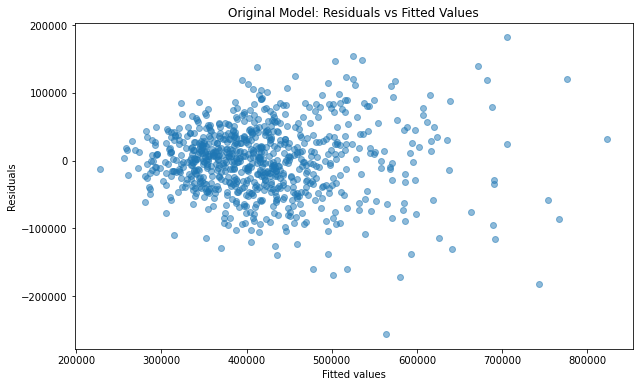

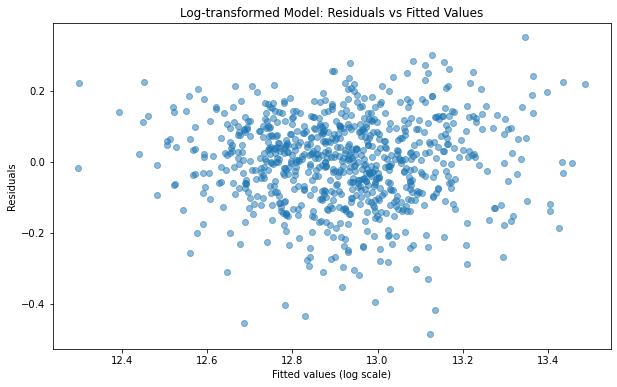

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns

# Create synthetic dataset
np.random.seed(42)
n_samples = 1000

# Generate predictor variables
square_footage = np.random.lognormal(mean=7.5, sigma=0.4, size=n_samples)
age = np.random.uniform(0, 50, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)

# Generate house prices with non-linear relationships and heteroscedasticity
base_price = 200000 + (square_footage * 100) + \
            (50000 * np.log(bedrooms)) - \
            (1000 * age) + \
            (np.random.normal(0, 50000 * (square_footage/np.mean(square_footage)), n_samples))

# Create DataFrame
df = pd.DataFrame({
    'price': base_price,
    'square_footage': square_footage,
    'age': age,
    'bedrooms': bedrooms
})

# Split data
X = df[['square_footage', 'age', 'bedrooms']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to fit and evaluate model
def evaluate_model(X_train, X_test, y_train, y_test, model_name):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return model, r2, rmse

# Original Model
model1, r2_1, rmse_1 = evaluate_model(X_train, X_test, y_train, y_test, "Original")

# Log-transformed price and square footage
X_train_log = X_train.copy()
X_test_log = X_test.copy()
X_train_log['square_footage'] = np.log(X_train_log['square_footage'])
X_test_log['square_footage'] = np.log(X_test_log['square_footage'])
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model2, r2_2, rmse_2 = evaluate_model(X_train_log, X_test_log, y_train_log, y_test_log, "Log-transformed")

# Square root transformation
X_train_sqrt = X_train.copy()
X_test_sqrt = X_test.copy()
X_train_sqrt['square_footage'] = np.sqrt(X_train_sqrt['square_footage'])
X_test_sqrt['square_footage'] = np.sqrt(X_test_sqrt['square_footage'])
y_train_sqrt = np.sqrt(y_train)
y_test_sqrt = np.sqrt(y_test)

model3, r2_3, rmse_3 = evaluate_model(X_train_sqrt, X_test_sqrt, y_train_sqrt, y_test_sqrt, "Square root")

# Results for each model
results = pd.DataFrame({
    'Model': ['Original', 'Log-transformed', 'Square root'],
    'R-squared': [r2_1, r2_2, r2_3],
    'RMSE': [rmse_1, rmse_2, rmse_3]
})

print("\nModel Performance Comparison:")
print(results)

# Plot residuals vs fitted values for original model
plt.figure(figsize=(10, 6))
y_pred_train = model1.predict(X_train)
residuals = y_train - y_pred_train
plt.scatter(y_pred_train, residuals, alpha=0.5)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Original Model: Residuals vs Fitted Values')
plt.show()

# Plot residuals vs fitted values for log-transformed model
plt.figure(figsize=(10, 6))
y_pred_train_log = model2.predict(X_train_log)
residuals_log = y_train_log - y_pred_train_log
plt.scatter(y_pred_train_log, residuals_log, alpha=0.5)
plt.xlabel('Fitted values (log scale)')
plt.ylabel('Residuals')
plt.title('Log-transformed Model: Residuals vs Fitted Values')
plt.show()